<a href="https://colab.research.google.com/github/anishkr-sahu/revision_ml/blob/main/ml_day_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# step -1 setup and data loading
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("/content/Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# step - 2 feature selection
x = df[['Age','Annual Income (k$)', 'Spending Score (1-100)']]
x.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [4]:
# step -3 scalling
sc = StandardScaler()
x_scaled = sc.fit_transform(x)
x_scaled

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992],
       [-1.20926872, -1.66266033,  1.00159627],
       [-0.27630176, -1.62449091, -1.71591298],
       [-1.13750203, -1.62449091,  1.70038436],
       [ 1.80493225, -1.58632148, -1.83237767],
       [-0.6351352 , -1.58632148,  0.84631002],
       [ 2.02023231, -1.58632148, -1.4053405 ],
       [-0.27630176, -1.58632148,  1.89449216],
       [ 1.37433211, -1.54815205, -1.36651894],
       [-1.06573534, -1.54815205,  1.04041783],
       [-0.13276838, -1.54815205, -1.44416206],
       [-1.20926872, -1.54815205,  1.11806095],
       [-0.27630176, -1.50998262, -0.59008772],
       [-1.3528021 , -1.50998262,  0.61338066],
       [ 0.94373197, -1.43364376, -0.82301709],
       [-0.27630176, -1.43364376,  1.8556706 ],
       [-0.27630176, -1.39547433, -0.590

In [5]:
# step -4 model
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
x_pca

array([[-6.15720019e-01, -1.76348088e+00],
       [-1.66579271e+00, -1.82074695e+00],
       [ 3.37861909e-01, -1.67479894e+00],
       [-1.45657325e+00, -1.77242992e+00],
       [-3.84652078e-02, -1.66274012e+00],
       [-1.48168526e+00, -1.73500173e+00],
       [ 1.09461665e+00, -1.56610230e+00],
       [-1.92630736e+00, -1.72111049e+00],
       [ 2.64517786e+00, -1.46084721e+00],
       [-9.70130513e-01, -1.63558108e+00],
       [ 2.49568861e+00, -1.47048914e+00],
       [-1.45688256e+00, -1.66436050e+00],
       [ 2.01018729e+00, -1.45329897e+00],
       [-1.41321072e+00, -1.61776746e+00],
       [ 1.00042965e+00, -1.49579176e+00],
       [-1.56943170e+00, -1.62502669e+00],
       [ 2.94060318e-01, -1.49425585e+00],
       [-1.31624924e+00, -1.57216383e+00],
       [ 1.31669910e+00, -1.37243404e+00],
       [-1.43679899e+00, -1.51039469e+00],
       [ 2.88561175e-01, -1.37988135e+00],
       [-1.26018513e+00, -1.45723906e+00],
       [ 1.66684303e+00, -1.27396755e+00],
       [-9.

In [6]:
# step - 5 variance ratio
print('Variance ratio: ', pca.explained_variance_ratio_)
print('Total variance: ', sum(pca.explained_variance_ratio_))

Variance ratio:  [0.44266167 0.33308378]
Total variance:  0.7757454566976747


In [7]:
print("components:\n", pca.components_)

components:
 [[ 0.70638235 -0.04802398 -0.70619946]
 [ 0.03014116  0.9988316  -0.03777499]]


### Determining Optimal Number of Clusters using Elbow Method

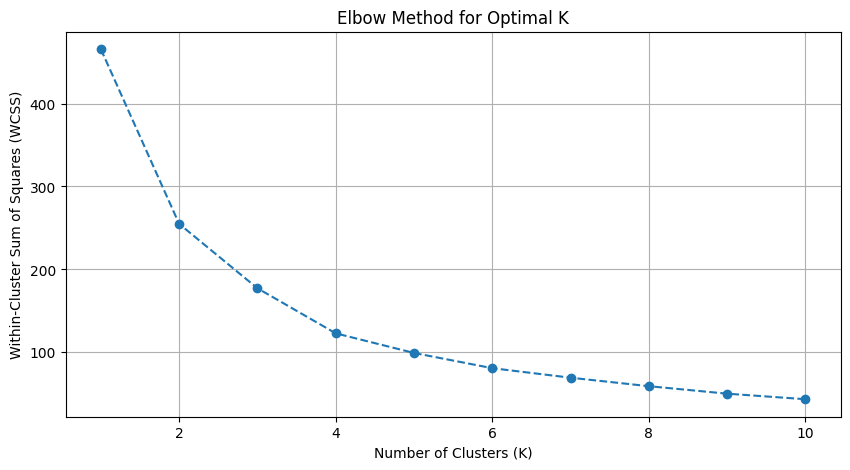

In [9]:
from sklearn.cluster import KMeans

wcss = [] # Within-Cluster Sum of Squares

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(x_pca)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

Based on the elbow plot, you can choose an optimal number of clusters (e.g., where the curve starts to bend). Let's assume we choose `k=5` for demonstration purposes (you might adjust this based on the plot).

### Applying K-Means Clustering

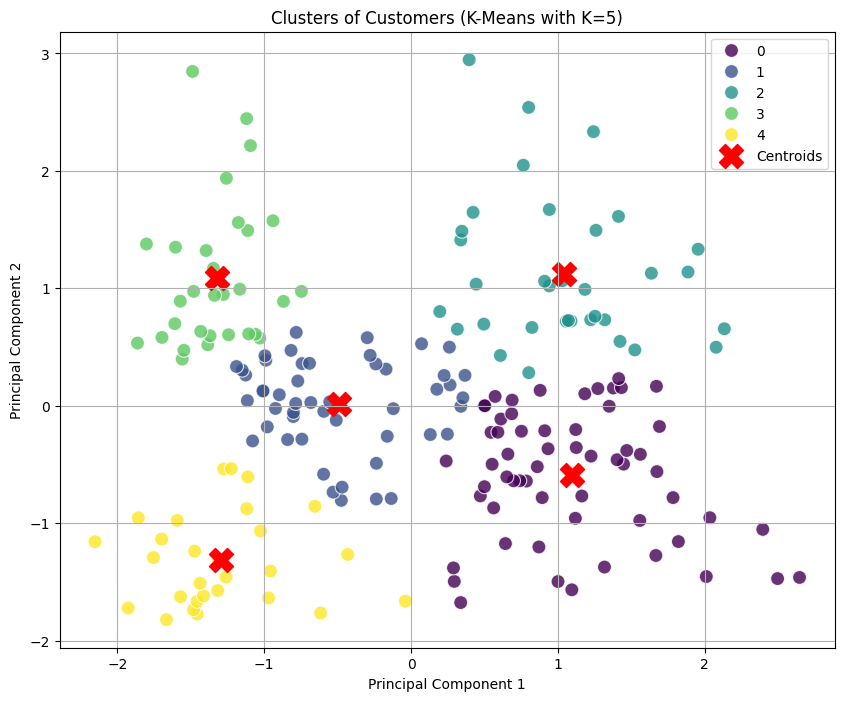

In [10]:
n_clusters = 5 # This can be adjusted based on the elbow method plot
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(x_pca)

# Visualize the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=y_kmeans, palette='viridis', legend='full', s=100, alpha=0.8)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title(f'Clusters of Customers (K-Means with K={n_clusters})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

### Visualizing Original Feature Loadings on PCA Plot

To understand what each principal component represents, we can visualize the loading vectors of the original features onto the PCA plot. These vectors show the direction and magnitude of each original feature's contribution to the principal components.

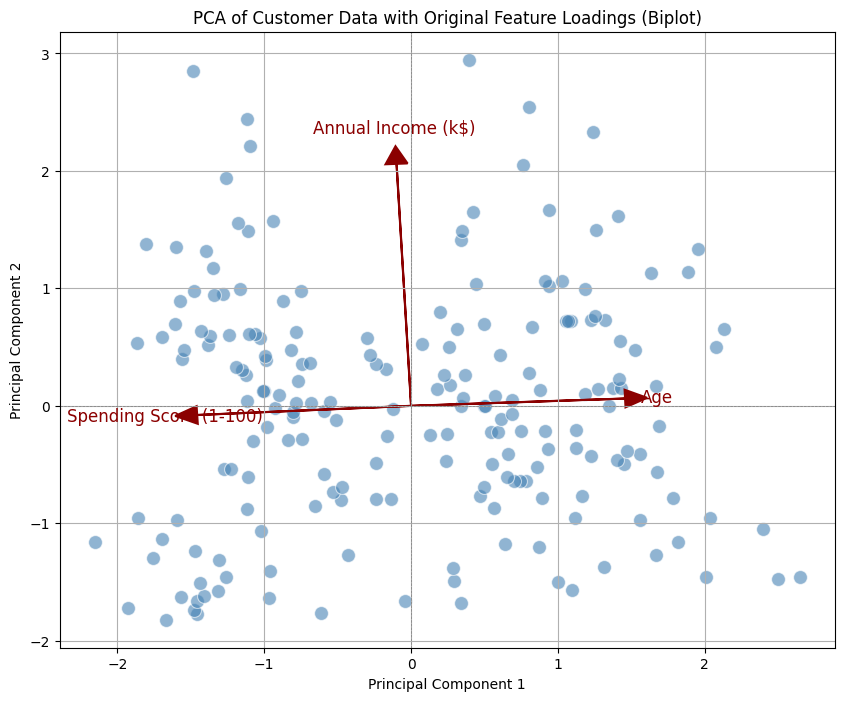

In [11]:
# Original feature names corresponding to the columns in `x`
original_features = x.columns

# Get the principal components (loadings) and transpose to get features as rows
loadings = pca.components_.T

plt.figure(figsize=(10, 8))

# Scatter plot of the PCA-transformed data (without clustering hues for clarity of loadings)
sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], color='steelblue', s=100, alpha=0.6)

# Define a scaling factor for the arrows for better visibility
# This scales the loading vectors to fit nicely within the plot's data range.
x_max_abs = abs(x_pca[:, 0]).max()
y_max_abs = abs(x_pca[:, 1]).max()
arrow_scale_factor = max(x_max_abs, y_max_abs) * 0.7 # Adjust this factor as needed for aesthetics

# Plot the loading vectors
for i, feature in enumerate(original_features):
    plt.arrow(0, 0,
              loadings[i, 0] * arrow_scale_factor,  # PC1 loading for feature i, scaled
              loadings[i, 1] * arrow_scale_factor,  # PC2 loading for feature i, scaled
              color='darkred', head_width=0.15, head_length=0.15, linewidth=1.5
             )
    # Add text labels for the features, slightly offset from the arrowheads
    plt.text(loadings[i, 0] * arrow_scale_factor * 1.15,
             loadings[i, 1] * arrow_scale_factor * 1.15,
             feature,
             color='darkred', ha='center', va='center', fontsize=12
            )

plt.title('PCA of Customer Data with Original Feature Loadings (Biplot)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.axhline(0, color='gray', linewidth=0.5, linestyle='--') # Add lines for PC1 axis
plt.axvline(0, color='gray', linewidth=0.5, linestyle='--') # Add lines for PC2 axis
plt.show()

/tmp/ipykernel_5218/427790290.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], palette='viridis')


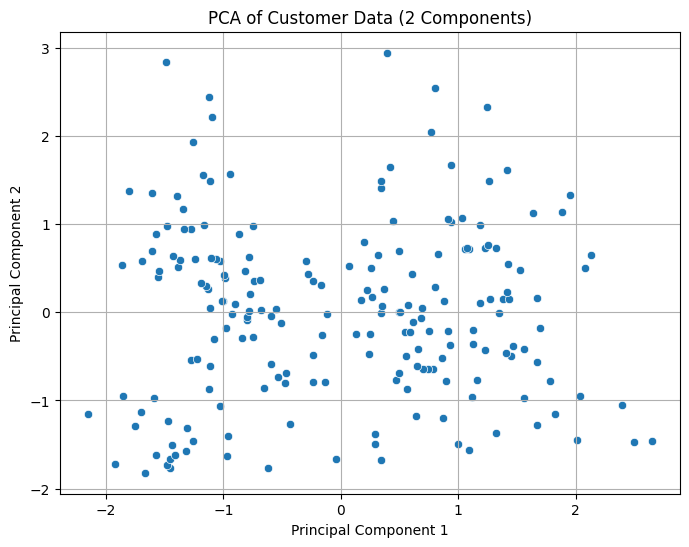

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], palette='viridis')
plt.title('PCA of Customer Data (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()